In [27]:
import pandas as pd

In [28]:
data = pd.read_csv('project_data/full_dataset_roberta.csv')

/var/folders/7d/2d_kq54s00v0272gkndgzxd80000gn/T/ipykernel_16080/51691811.py:1: DtypeWarning: Columns (27,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('project_data/full_dataset_roberta.csv')


In [29]:
data.columns

Index(['tweet_id', 'user_id', 'created_at', 'ANEW_Valence', 'ANEW_Dominance',
       'ANEW_Arousal', 'Happiness', 'NRC_anger', 'NRC_anticipation',
       'NRC_disgust', 'NRC_fear', 'NRC_joy', 'NRC_sadness', 'NRC_surprise',
       'NRC_trust', 'NRC_negative', 'NRC_positive', 'Afinn_Valence',
       'OpinionFinder', 'VADER', 'male', 'female', '19-29', '30-39', '<=18',
       '>=40', 'botscore', 'time_indication', 'diag_start_interval',
       'diag_end_interval', 'diagnosis', 'non-org', 'is-org',
       'group_depression', 'group_anxiety', 'comorbid', 'cohort',
       'inferred_timezone', 'timezone_loss', 'day_of_week', 'female_prop',
       'gender', 'VADER_NEG', 'VADER_NEU', 'VADER_POS', 'ROBERTA_NA',
       'neu_prob', 'pos_prob'],
      dtype='object')

In [30]:
OUTCOME_VAR = 'ROBERTA_NA'

In [31]:
data_aggregated_level = data.groupby('user_id').agg({OUTCOME_VAR : 'mean', 'group_depression' : 'first', 'group_anxiety' : 'first'})[[OUTCOME_VAR, 'group_depression', 'group_anxiety']].reset_index().rename({OUTCOME_VAR : 'mean'}, axis=1)
data_aggregated_spread = data.groupby('user_id').std(numeric_only=True)[OUTCOME_VAR].reset_index().rename({OUTCOME_VAR : 'std'}, axis=1)

In [32]:
data = pd.merge(
    data_aggregated_level,
    data_aggregated_spread,
    how='inner',
    on='user_id'
)

In [33]:
data

,user_id,mean,group_depression,group_anxiety,std
0,uANX011,0.269805,False,True,0.299237
1,uANX014,0.280747,False,True,0.318615
2,uANX017,0.269009,False,True,0.348302
3,uANX021,0.229888,False,True,0.308923
4,uANX038,0.352937,False,True,0.339480
...,...,...,...,...,...
455,uPHO001,0.421286,False,True,0.330596
456,uPHO006,0.310070,False,True,0.318098
457,uPHO007,0.238355,False,True,0.312365
458,uPHO008,0.259591,False,True,0.338176


In [34]:
depression_patients = data[data['group_depression'].fillna(False)]
anxiety_patients = data[data['group_anxiety'].fillna(False)]

In [35]:
pairs = []

for idx, row in depression_patients.iterrows():
    best_fit = anxiety_patients.loc[(anxiety_patients['mean'] - row['mean']).abs() == (anxiety_patients['mean'] - row['mean']).abs().min()]
    pairs.append({
        'depression_id' : row['user_id'],
        'anxiety_id' : best_fit['user_id'].values[0],
        'depression_mean' : row['mean'],
        'anxiety_mean' : best_fit['mean'].values[0],
        'depression_std' : row['std'],
        'anxiety_std' : best_fit['std'].values[0],
    })

In [36]:
df = pd.DataFrame(pairs)
df['mean_diff'] = (df['anxiety_mean'] - df['depression_mean']).abs()

df_best = df.loc[df['mean_diff'] < df['mean_diff'].quantile(0.8)]

df_best

,depression_id,anxiety_id,depression_mean,anxiety_mean,depression_std,anxiety_std,mean_diff
0,uDEP000,uANX756,0.316182,0.317623,0.308169,0.329200,0.001442
2,uDEP007,uGAD003,0.288456,0.287647,0.325407,0.337070,0.000809
3,uDEP008,uOCD220,0.263974,0.264032,0.328822,0.337321,0.000058
4,uDEP013,uANX596,0.175184,0.176238,0.257998,0.278954,0.001053
5,uDEP019,uANX756,0.317764,0.317623,0.390036,0.329200,0.000141
...,...,...,...,...,...,...,...
224,uDEP965,uOCD149,0.212004,0.211902,0.323288,0.277164,0.000102
225,uDEP970,uGAD032,0.460313,0.461375,0.365854,0.392928,0.001061
227,uDEP998,uOCD206,0.244950,0.245538,0.337582,0.316329,0.000588
228,uDYS006,uGAD014,0.423480,0.423720,0.351402,0.341421,0.000240


In [37]:
# Motivate this more

In [38]:
from scipy import stats  

df_ = df_best.dropna()

stats.ttest_rel(
    df_['depression_std'],
    df_['anxiety_std'])

TtestResult(statistic=np.float64(-2.1931944974391677), pvalue=np.float64(0.029554064684833126), df=np.int64(183))

In [39]:
df_.mean(numeric_only=True)

depression_mean    0.292635
anxiety_mean       0.292674
depression_std     0.321486
anxiety_std        0.324833
mean_diff          0.000529
dtype: float64

/var/folders/7d/2d_kq54s00v0272gkndgzxd80000gn/T/ipykernel_16080/1069271762.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax[0].boxplot(
/var/folders/7d/2d_kq54s00v0272gkndgzxd80000gn/T/ipykernel_16080/1069271762.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax[1].boxplot(


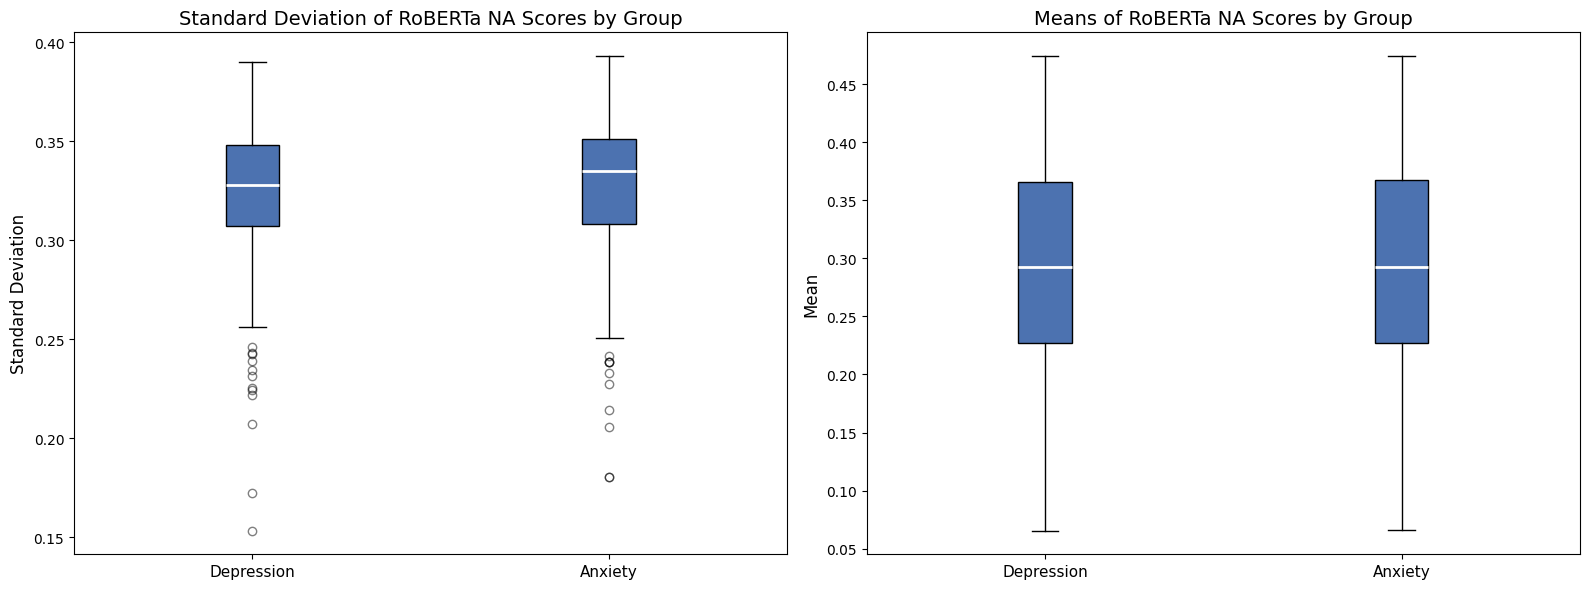

In [40]:
import matplotlib.pyplot as plt

# Prepare data
data = [df_['depression_std'].dropna(), df_['anxiety_std'].dropna()]
labels = ['Depression', 'Anxiety']

# Set figure style
#plt.style.use('seaborn-vignette')  # or try 'ggplot', 'seaborn-whitegrid', etc.
fig, ax = plt.subplots(1,2,figsize=(16, 6))

# Create the boxplot
box = ax[0].boxplot(
    data,
    labels=labels,
    patch_artist=True,         # enable fill color
    boxprops=dict(facecolor='#4C72B0', color='black'),
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(marker='o', color='black', alpha=0.5)
)

# Aesthetics
ax[0].set_title('Standard Deviation of RoBERTa NA Scores by Group', fontsize=14)
ax[0].set_ylabel('Standard Deviation', fontsize=12)
#ax.grid(True, linestyle='--', alpha=0.6)
ax[0].tick_params(axis='x', labelsize=11)
ax[0].tick_params(axis='y', labelsize=10)


data = [df_['depression_mean'].dropna(), df_['anxiety_mean'].dropna()]
labels = ['Depression', 'Anxiety']

# Set figure style
#plt.style.use('seaborn-vignette')  # or try 'ggplot', 'seaborn-whitegrid', etc.

# Create the boxplot
box = ax[1].boxplot(
    data,
    labels=labels,
    patch_artist=True,         # enable fill color
    boxprops=dict(facecolor='#4C72B0', color='black'),
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(marker='o', color='black', alpha=0.5)
)

# Aesthetics
ax[1].set_title('Means of RoBERTa NA Scores by Group', fontsize=14)
ax[1].set_ylabel('Mean', fontsize=12)
#ax.grid(True, linestyle='--', alpha=0.6)
ax[1].tick_params(axis='x', labelsize=11)
ax[1].tick_params(axis='y', labelsize=10)
plt.tight_layout()

# Show the plot
plt.savefig('figures/boxplot_depression_anxiety_roberta.png', dpi=400, bbox_inches='tight')
